# Fire / Smoke / Non-Fire Detection — YOLO12s Training 



## 1. Install packages

In [7]:
!pip install -q ultralytics roboflow


## 2. Imports

In [8]:
import os
import time
import shutil
import glob
from pathlib import Path

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from ultralytics import YOLO
from roboflow import Roboflow

print("Setup done")


Setup done


## 3. Dataset download (Roboflow API)

Set your own Roboflow API key in `ROBOFLOW_API_KEY` below. The key can be found in the Roboflow dashboard -> Settings -> API Keys.

In [9]:
ROBOFLOW_API_KEY = "eFz0r5rdHpUUABPht8JV"   

WORKSPACE = "md-s-workspace"
PROJECT   = "fire_smoke_detection-tmqte"
VERSION   = 4

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download("yolov11")   # yolov11 format = yolo11/26 compatible

DATASET_DIR = dataset.location
print("Dataset downloaded to:", DATASET_DIR)

loading Roboflow workspace...
loading Roboflow project...
Dataset downloaded to: /kaggle/working/fire_smoke_detection-4


## 4. Dataset check — classes, per-class image/box count

Before starting training, check the class distribution (whether there's imbalance between fire vs smoke vs nonfire).

Annotated classes: ['Fire', 'Smoke']
Number of annotated classes: 2

Note: 'Nonfire' is not an annotated class — those images are already present
in the dataset as 'background' (label file exists but is completely empty). YOLO
uses these as negative samples during train/eval automatically. No separate class needed.

train: 8089 total images
   Fire: 9162 boxes
   Smoke: 4157 boxes
   Nonfire (background, no box): 1419 images

valid: 1706 total images
   Fire: 1946 boxes
   Smoke: 921 boxes
   Nonfire (background, no box): 275 images

test: 1715 total images
   Fire: 1912 boxes
   Smoke: 878 boxes
   Nonfire (background, no box): 287 images


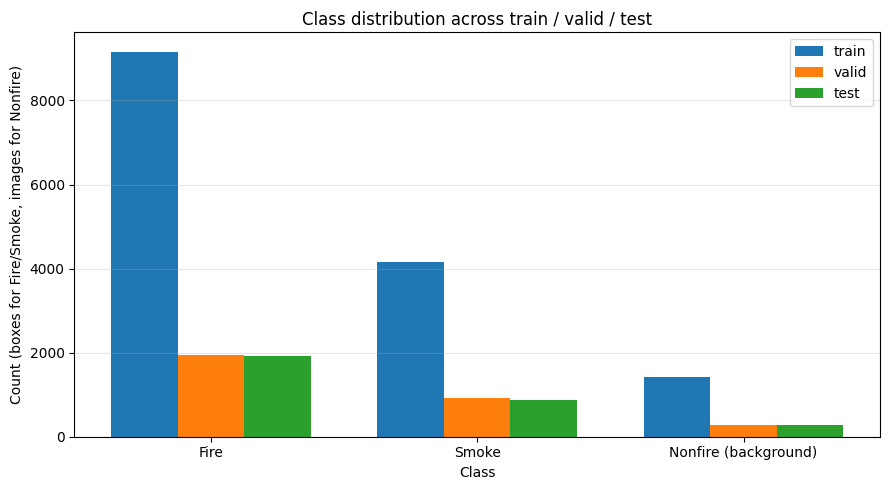

In [10]:
DATA_YAML = os.path.join(DATASET_DIR, "data.yaml")

with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

CLASS_NAMES = data_cfg["names"]
NUM_CLASSES = data_cfg["nc"]
print("Annotated classes:", CLASS_NAMES)
print("Number of annotated classes:", NUM_CLASSES)
print()
print("Note: 'Nonfire' is not an annotated class — those images are already present")
print("in the dataset as 'background' (label file exists but is completely empty). YOLO")
print("uses these as negative samples during train/eval automatically. No separate class needed.")

def count_boxes_per_class(labels_dir, num_classes):
    counts = np.zeros(num_classes, dtype=int)
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    n_background = 0
    for lf in label_files:
        with open(lf, "r") as f:
            lines = [line.strip() for line in f if line.strip()]
        if len(lines) == 0:
            n_background += 1   # empty label file = background / nonfire image
            continue
        for line in lines:
            cls_id = int(line.split()[0])
            counts[cls_id] += 1
    return counts, len(label_files), n_background

splits = ["train", "valid", "test"]
split_counts = {}
split_backgrounds = {}

for split in splits:
    labels_path = os.path.join(DATASET_DIR, split, "labels")
    if os.path.exists(labels_path):
        counts, n_images, n_bg = count_boxes_per_class(labels_path, NUM_CLASSES)
        split_counts[split] = counts
        split_backgrounds[split] = n_bg
        print(f"\n{split}: {n_images} total images")
        for name, c in zip(CLASS_NAMES, counts):
            print(f"   {name}: {c} boxes")
        print(f"   Nonfire (background, no box): {n_bg} images")

# ---- plot class distribution (Fire, Smoke, Nonfire) across splits ----
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(NUM_CLASSES + 1)   # +1 for nonfire/background
width = 0.25
plot_labels = list(CLASS_NAMES) + ["Nonfire (background)"]

for i, split in enumerate(split_counts.keys()):
    values = list(split_counts[split]) + [split_backgrounds[split]]
    ax.bar(x + i * width, values, width, label=split)

ax.set_xlabel("Class")
ax.set_ylabel("Count (boxes for Fire/Smoke, images for Nonfire)")
ax.set_title("Class distribution across train / valid / test")
ax.set_xticks(x + width)
ax.set_xticklabels(plot_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/class_distribution.png", dpi=200)
plt.show()

## 5. Config — paths, augmentation, epochs

All paths are centralized in this cell, so that even if the Kaggle session ends, everything under
`/kaggle/working/` (weights, plots, csv) can still be downloaded.

In [14]:
PROJECT_DIR = "/kaggle/working/runs"
RUN_NAME    = "yolo12s_baseline"
FINAL_DIR   = "/kaggle/working/final_outputs"

os.makedirs(FINAL_DIR, exist_ok=True)

IMGSZ    = 640          # kept same as the earlier baseline, for a fair comparison
BATCH    = 12
EPOCHS   = 150          # Step 1: more epochs (early stopping prevents overtraining)
PATIENCE = 30           # early stopping patience
SEED     = 42

# Step 1: augmentation config (bumped up from the baseline)
AUG_PARAMS = dict(
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.5,
    degrees=10.0,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    close_mosaic=20,
)
print("Config ready. imgsz =", IMGSZ, "| epochs =", EPOCHS, "| batch =", BATCH)

Config ready. imgsz = 640 | epochs = 150 | batch = 12


## 6. Train YOLO26s (Step 2: model size step-up + Step 1: augmentation)

In [ ]:
model = YOLO("yolo12s.pt")   # pretrained COCO checkpoint, "s" size (step-up from n)

train_results = model.train(
    data=DATA_YAML,
    imgsz=IMGSZ,
    batch=BATCH,
    epochs=EPOCHS,
    patience=PATIENCE,
    seed=SEED,
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    **AUG_PARAMS,
)

RUN_DIR = os.path.join(PROJECT_DIR, RUN_NAME)
BEST_PT = os.path.join(RUN_DIR, "weights", "best.pt")
print("Training done. best.pt at:", BEST_PT)

Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire_smoke_detection-4/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo12s_basel

In [15]:
LAST_PT = "/kaggle/working/runs/yolo12s_baseline/weights/last.pt"
 
import os
print("last.pt exists:", os.path.exists(LAST_PT))   # False হলে resume করার কিছু নেই, এখানেই থামো
 
resume_model = YOLO(LAST_PT)
resume_results = resume_model.train(resume=True)
 
RUN_DIR = os.path.join(PROJECT_DIR, RUN_NAME)
BEST_PT = os.path.join(RUN_DIR, "weights", "best.pt")
print("Resumed training done. best.pt at:", BEST_PT)

last.pt exists: True
Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=12, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/fire_smoke_detection-4/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.02, hsv_s=0.7, hsv_v=0.5, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/runs/yolo12s_baseline/weights/last.pt,

## 7. Training curves — loss, mAP, precision, recall vs epoch

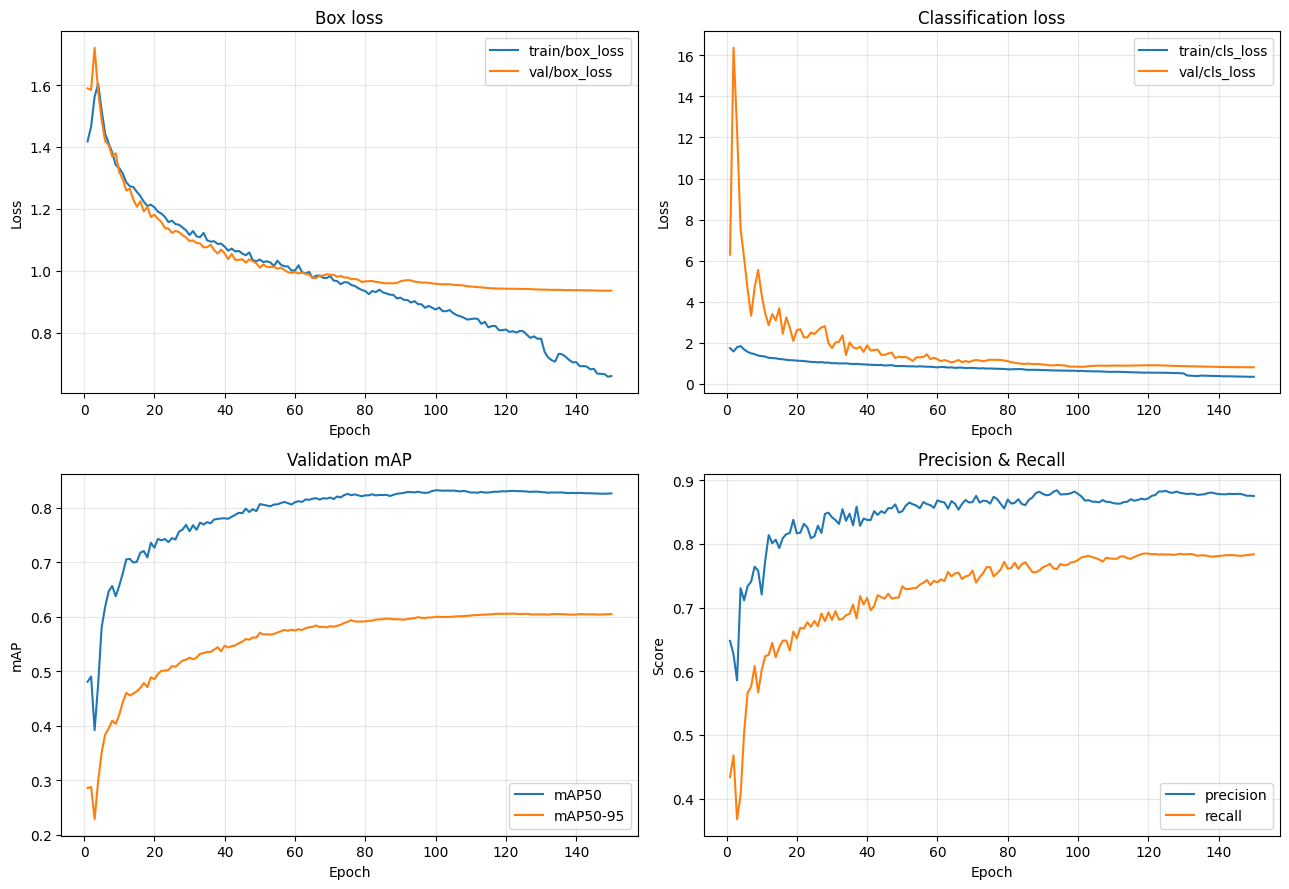

In [16]:
results_csv = os.path.join(RUN_DIR, "results.csv")
r = pd.read_csv(results_csv)
r.columns = [c.strip() for c in r.columns]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- box loss ---
axes[0, 0].plot(r["epoch"], r["train/box_loss"], label="train/box_loss")
axes[0, 0].plot(r["epoch"], r["val/box_loss"], label="val/box_loss")
axes[0, 0].set_title("Box loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# --- cls loss ---
axes[0, 1].plot(r["epoch"], r["train/cls_loss"], label="train/cls_loss")
axes[0, 1].plot(r["epoch"], r["val/cls_loss"], label="val/cls_loss")
axes[0, 1].set_title("Classification loss")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# --- mAP ---
axes[1, 0].plot(r["epoch"], r["metrics/mAP50(B)"], label="mAP50")
axes[1, 0].plot(r["epoch"], r["metrics/mAP50-95(B)"], label="mAP50-95")
axes[1, 0].set_title("Validation mAP")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("mAP")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# --- precision / recall ---
axes[1, 1].plot(r["epoch"], r["metrics/precision(B)"], label="precision")
axes[1, 1].plot(r["epoch"], r["metrics/recall(B)"], label="recall")
axes[1, 1].set_title("Precision & Recall")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Score")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "training_curves.png"), dpi=300)
plt.show()


## 8. Final validation metrics (using best.pt)

Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12s summary (fused): 159 layers, 9,231,654 parameters, 0 gradients, 23.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1292.9±318.0 MB/s, size: 46.7 KB)
val: Scanning /kaggle/working/fire_smoke_detection-4/valid/labels.cache... 1706 images, 275 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1706/1706 650.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 107/107 3.6it/s 30.1s0.3s
                   all       1706       2867      0.878      0.783      0.831      0.606
                  Fire       1173       1946      0.881      0.817       0.86      0.617
                 Smoke        680        921      0.876      0.749      0.801      0.594
Speed: 0.9ms preprocess, 13.5ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
     class     AP50  AP50-95
      Fire 0.859566 0.617

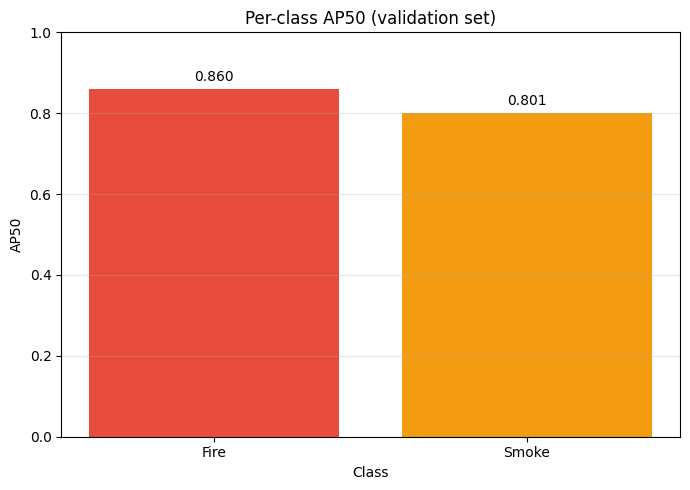

In [17]:
best_model = YOLO(BEST_PT)
val_metrics = best_model.val(data=DATA_YAML, imgsz=IMGSZ, split="val")

metrics_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "AP50": val_metrics.box.ap50,
    "AP50-95": val_metrics.box.ap,
})

overall_row = pd.DataFrame({
    "class": ["ALL (mean)"],
    "AP50": [val_metrics.box.map50],
    "AP50-95": [val_metrics.box.map],
})

metrics_table = pd.concat([metrics_table, overall_row], ignore_index=True)
print(metrics_table.to_string(index=False))

metrics_table.to_csv(os.path.join(FINAL_DIR, "val_metrics.csv"), index=False)

# per-class AP50 bar chart
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(CLASS_NAMES, val_metrics.box.ap50, color=["#e74c3c", "#f39c12", "#2ecc71"][:NUM_CLASSES])
ax.set_ylabel("AP50")
ax.set_xlabel("Class")
ax.set_title("Per-class AP50 (validation set)")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)
for i, v in enumerate(val_metrics.box.ap50):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "per_class_AP50.png"), dpi=300)
plt.show()


## 8.5 Test set evaluation (held-out, model has never seen these images)


Ultralytics 8.4.129 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 629.5±270.1 MB/s, size: 38.6 KB)
val: Scanning /kaggle/working/fire_smoke_detection-4/test/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.1Kit/s 1.6s<0.0s
val: New cache created: /kaggle/working/fire_smoke_detection-4/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 3.6it/s 30.3s0.3s
                   all       1715       2790      0.873      0.762      0.826      0.625
                  Fire       1194       1912      0.886      0.816      0.873      0.653
                 Smoke        629        878       0.86      0.707      0.779      0.597
Speed: 0.9ms preprocess, 13.5ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
=== TEST SET METRICS (held-out) ===
     class     AP50  AP50

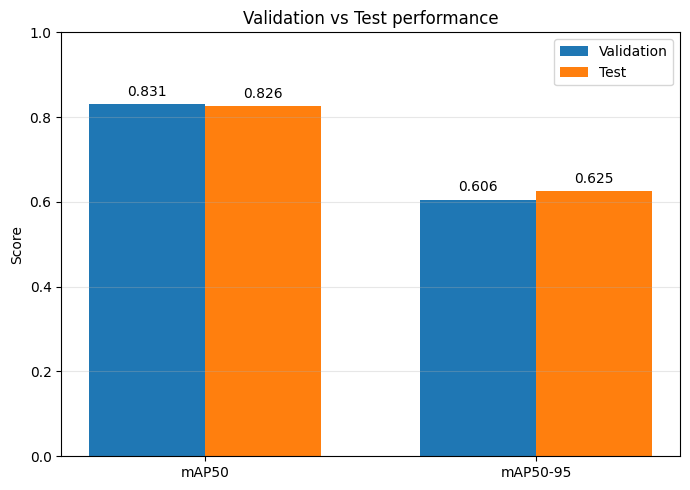


Note: if there's a large gap between val and test scores (val much higher),
the model is overfitting to the val set — a sign of a generalization problem.


In [18]:
test_metrics = best_model.val(data=DATA_YAML, imgsz=IMGSZ, split="test")

test_table = pd.DataFrame({
    "class": CLASS_NAMES,
    "AP50": test_metrics.box.ap50,
    "AP50-95": test_metrics.box.ap,
})
test_overall = pd.DataFrame({
    "class": ["ALL (mean)"],
    "AP50": [test_metrics.box.map50],
    "AP50-95": [test_metrics.box.map],
})
test_table = pd.concat([test_table, test_overall], ignore_index=True)

print("=== TEST SET METRICS (held-out) ===")
print(test_table.to_string(index=False))
print(f"\nPrecision: {test_metrics.box.mp:.4f}  |  Recall: {test_metrics.box.mr:.4f}")

test_table.to_csv(os.path.join(FINAL_DIR, "test_metrics.csv"), index=False)

# --- val vs test comparison bar chart (to check overfitting/generalization gap) ---
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
val_scores = [val_metrics.box.map50, val_metrics.box.map]
test_scores = [test_metrics.box.map50, test_metrics.box.map]

ax.bar(x - width/2, val_scores, width, label="Validation")
ax.bar(x + width/2, test_scores, width, label="Test")
ax.set_xticks(x)
ax.set_xticklabels(["mAP50", "mAP50-95"])
ax.set_ylabel("Score")
ax.set_title("Validation vs Test performance")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for i, (v, t) in enumerate(zip(val_scores, test_scores)):
    ax.text(i - width/2, v + 0.02, f"{v:.3f}", ha="center")
    ax.text(i + width/2, t + 0.02, f"{t:.3f}", ha="center")
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "val_vs_test.png"), dpi=300)
plt.show()

print("\nNote: if there's a large gap between val and test scores (val much higher),")
print("the model is overfitting to the val set — a sign of a generalization problem.")

## 8.6 Test set — confusion matrix & PR curve (on the test split, not val)

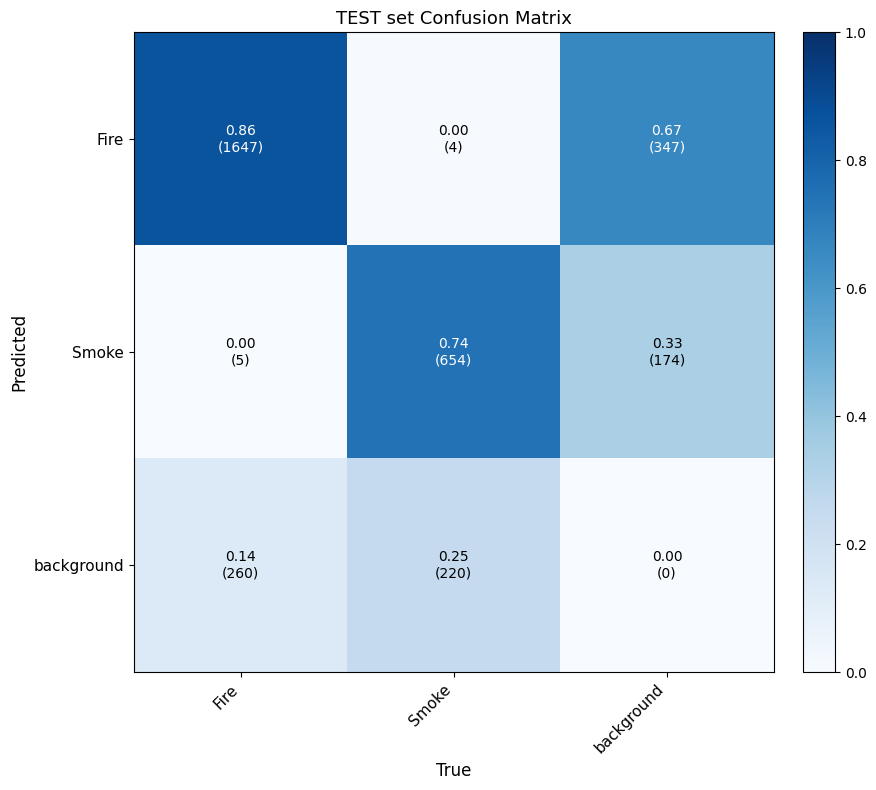

Raw confusion matrix counts (rows = predicted, columns = true):
                 true_Fire  true_Smoke  true_background
pred_Fire             1647           4              347
pred_Smoke               5         654              174
pred_background        260         220                0
TEST set Precision-Recall Curve:


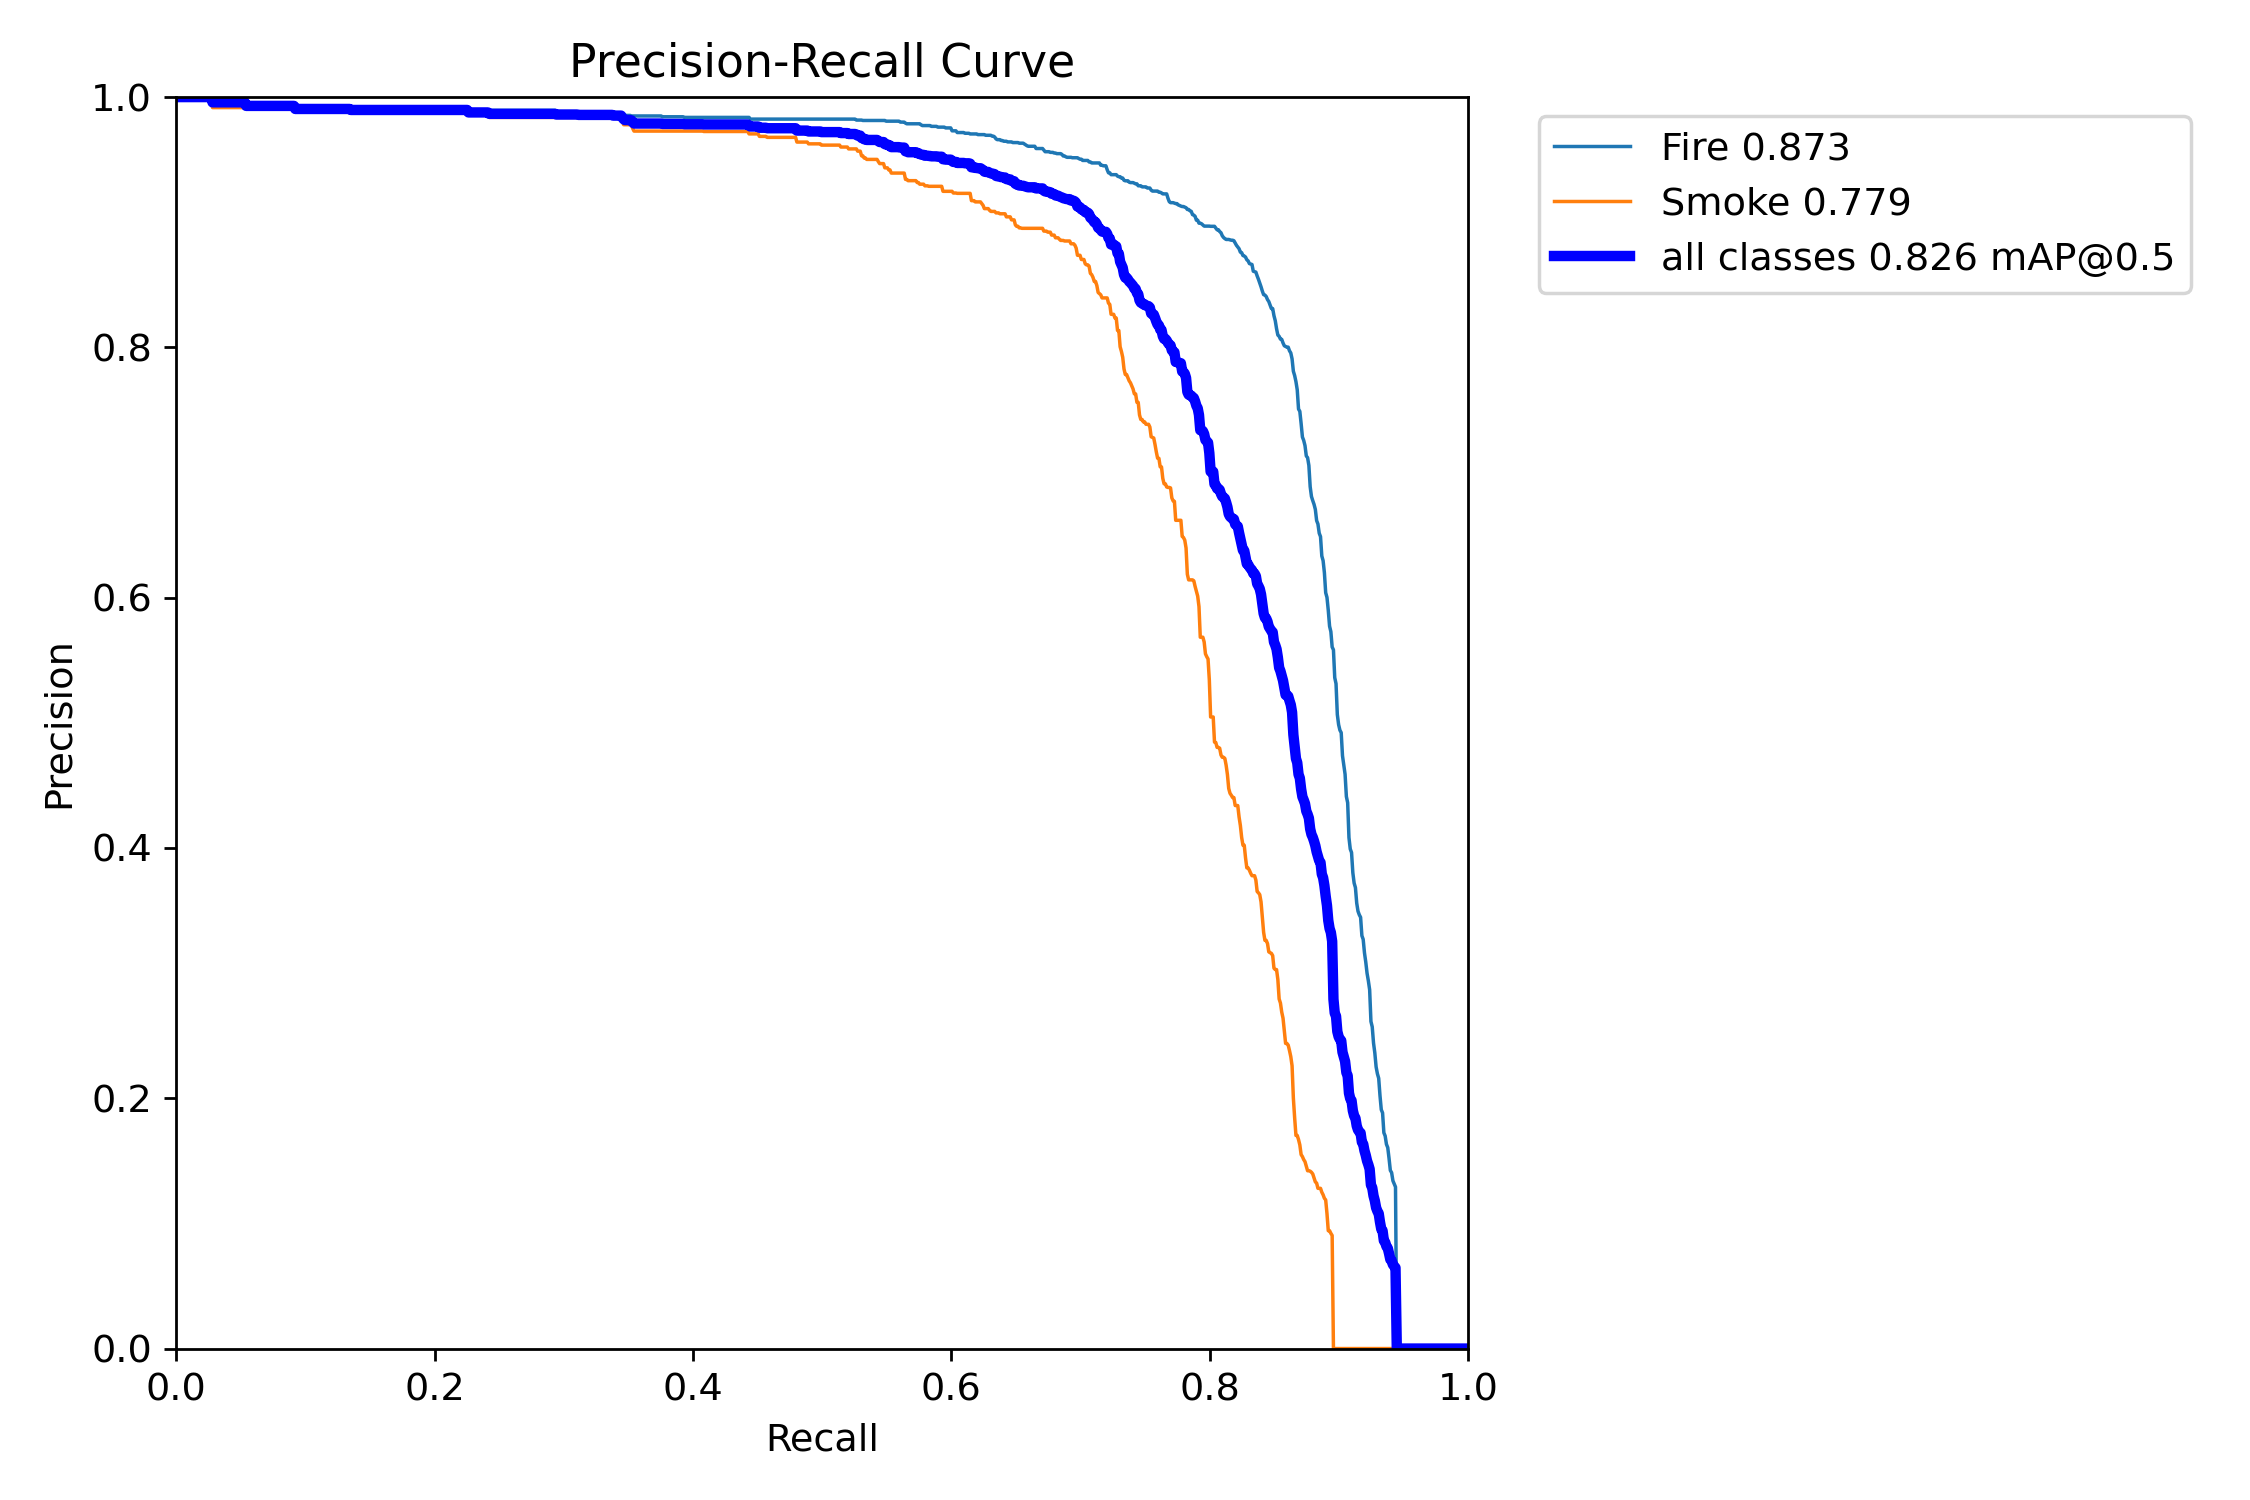

In [20]:
test_run_dir = test_metrics.save_dir

# ---- Confusion matrix, plotted manually for a clear result (no blank cells) ----
cm = test_metrics.confusion_matrix.matrix   # raw counts, shape (nc+1, nc+1), last row/col = background
labels = list(CLASS_NAMES) + ["background"]

# column-wise normalize (each column = one true class, sums to 1)
cm_norm = cm.astype(float)
col_sums = cm_norm.sum(axis=0)
col_sums[col_sums == 0] = 1   # avoid divide-by-zero
cm_norm = cm_norm / col_sums

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("True", fontsize=12)
ax.set_ylabel("Predicted", fontsize=12)
ax.set_title("TEST set Confusion Matrix", fontsize=13)

# write both the normalized value AND the raw count in every cell -- nothing left blank.
# Raw counts matter because normalized-only hides scale: e.g. "0.85" recall for Fire could
# mean 85/100 or 850/1000, and it is the only way to see how many background images were
# actually misclassified as Fire/Smoke vs how many predictions of each class were correct.
# Note: the background/background cell IS meaningful here (fraction of missed
# detections among the "background" true-column, i.e. false negatives), so it
# gets a real computed value like every other cell, not a placeholder.
for i in range(len(labels)):
    for j in range(len(labels)):
        raw_count = int(cm[i, j])
        text = f"{cm_norm[i, j]:.2f}\n({raw_count})"
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "test_confusion_matrix.png"), dpi=300)
plt.show()

# ---- also save the raw (un-normalized) counts as a CSV, for exact numbers in the report ----
raw_cm_df = pd.DataFrame(cm.astype(int), index=[f"pred_{l}" for l in labels], columns=[f"true_{l}" for l in labels])
raw_cm_df.to_csv(os.path.join(FINAL_DIR, "test_confusion_matrix_raw_counts.csv"))
print("Raw confusion matrix counts (rows = predicted, columns = true):")
print(raw_cm_df.to_string())

# ---- PR curve -- show Ultralytics' original PNG directly (re-plotting with matplotlib
# makes it blurry, so IPython Image is used to keep the original resolution) ----
from IPython.display import Image as IPImage, display

pr_path = os.path.join(test_run_dir, "BoxPR_curve.png")
if os.path.exists(pr_path):
    print("TEST set Precision-Recall Curve:")
    display(IPImage(filename=pr_path, width=800))
    shutil.copy(pr_path, os.path.join(FINAL_DIR, "test_BoxPR_curve.png"))
else:
    print("Not found:", pr_path)

## 8.7 Visual predictions — what the model says on sample test images (ground truth vs predicted box)



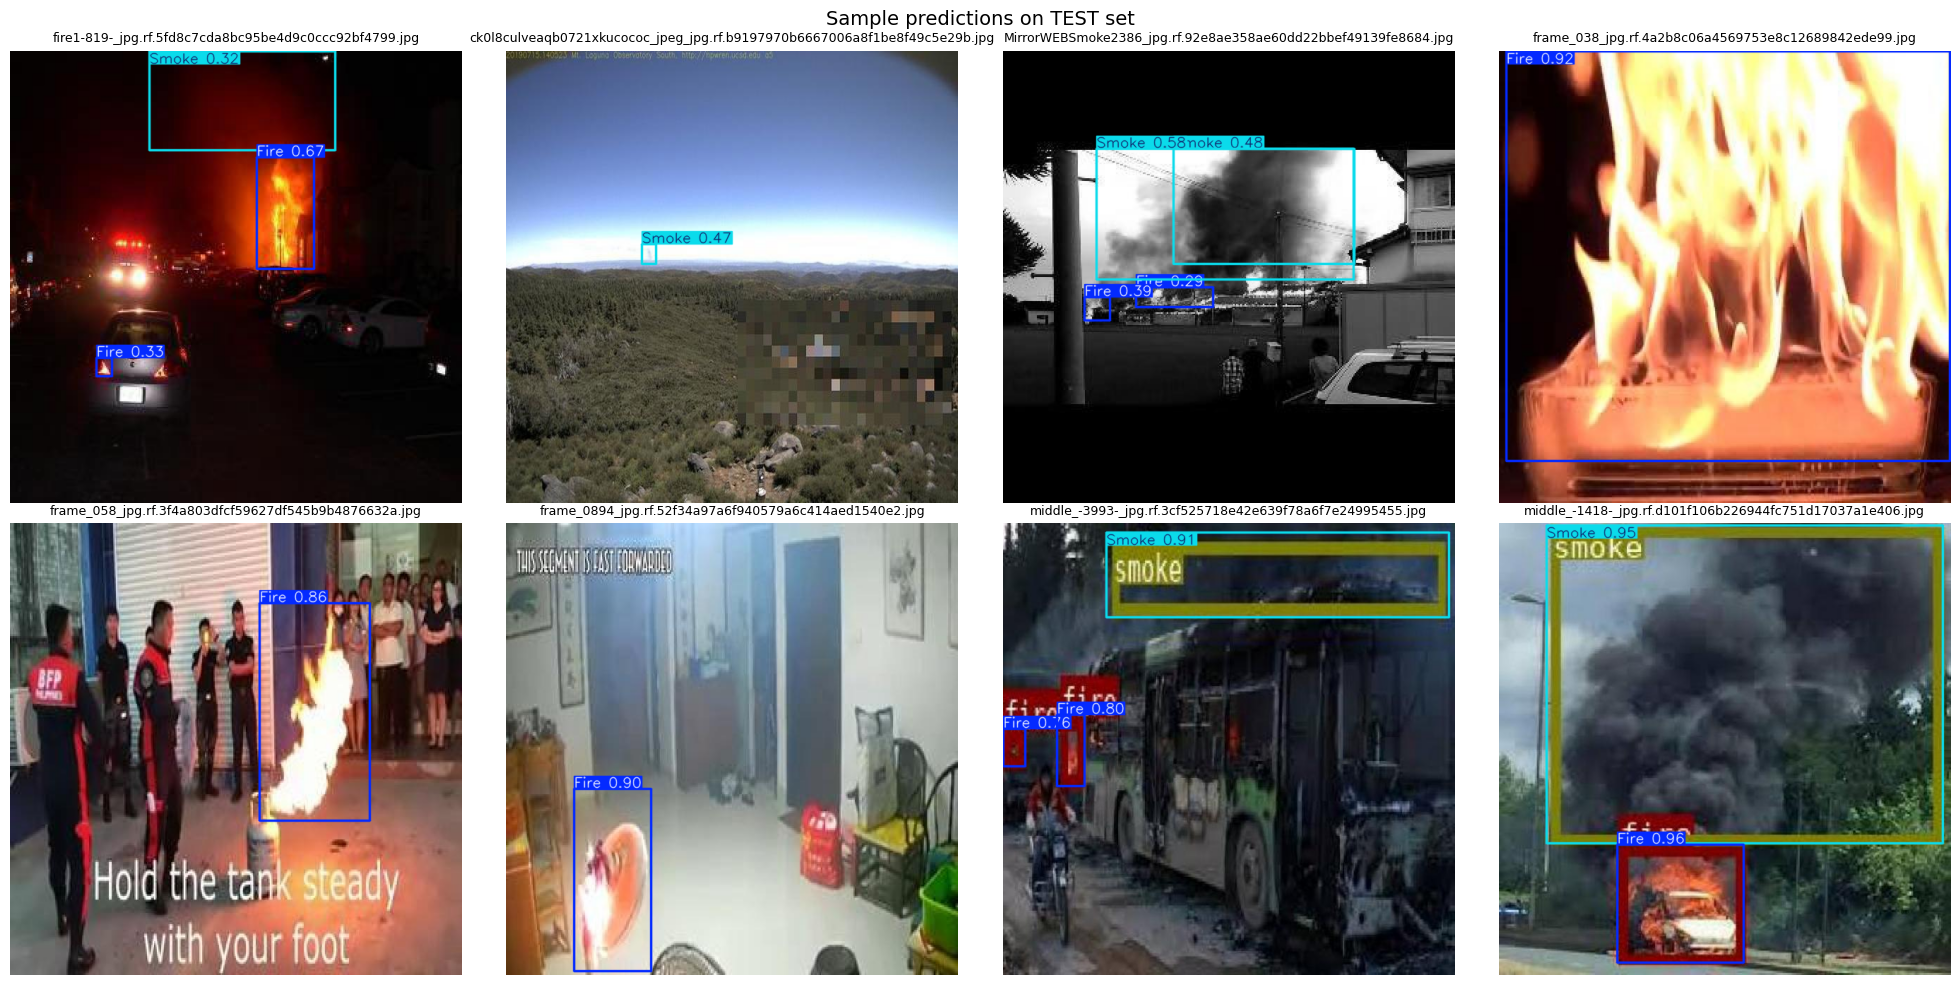

These images were randomly selected from the test set — the model has never seen them before.
Bounding box + class label + confidence score are all drawn automatically.


In [22]:
import random

test_images_all = glob.glob(os.path.join(DATASET_DIR, "test", "images", "*"))
random.seed(SEED)
sample_images = random.sample(test_images_all, min(8, len(test_images_all)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_images):
    pred = best_model.predict(img_path, imgsz=IMGSZ, conf=0.25, verbose=False)[0]
    plotted = pred.plot()   # numpy array, boxes + class + confidence already drawn
    plotted_rgb = plotted[..., ::-1]   # BGR -> RGB
    ax.imshow(plotted_rgb)
    ax.axis("off")
    ax.set_title(os.path.basename(img_path), fontsize=9)

plt.suptitle("Sample predictions on TEST set", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "sample_predictions.png"), dpi=300)
plt.show()

print("These images were randomly selected from the test set — the model has never seen them before.")
print("Bounding box + class label + confidence score are all drawn automatically.")

## 9. Confusion matrix & Precision-Recall curve

Ultralytics generates these plots automatically during validation and saves them in the run folder — loading and showing them directly here.

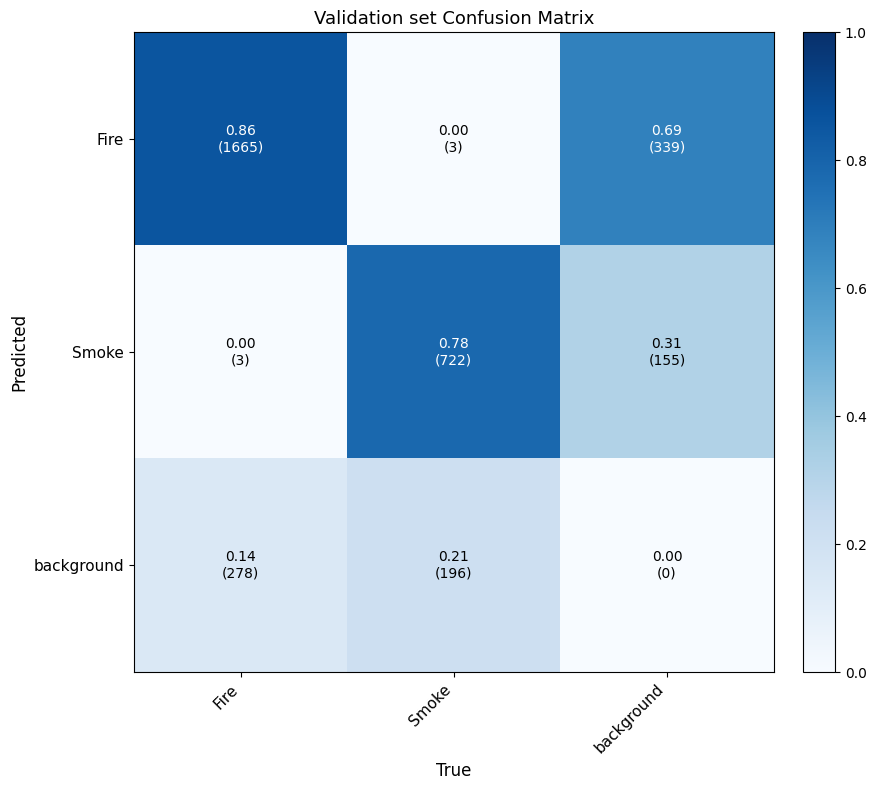

Raw confusion matrix counts (rows = predicted, columns = true):
                 true_Fire  true_Smoke  true_background
pred_Fire             1665           3              339
pred_Smoke               3         722              155
pred_background        278         196                0
Validation set Precision-Recall Curve:


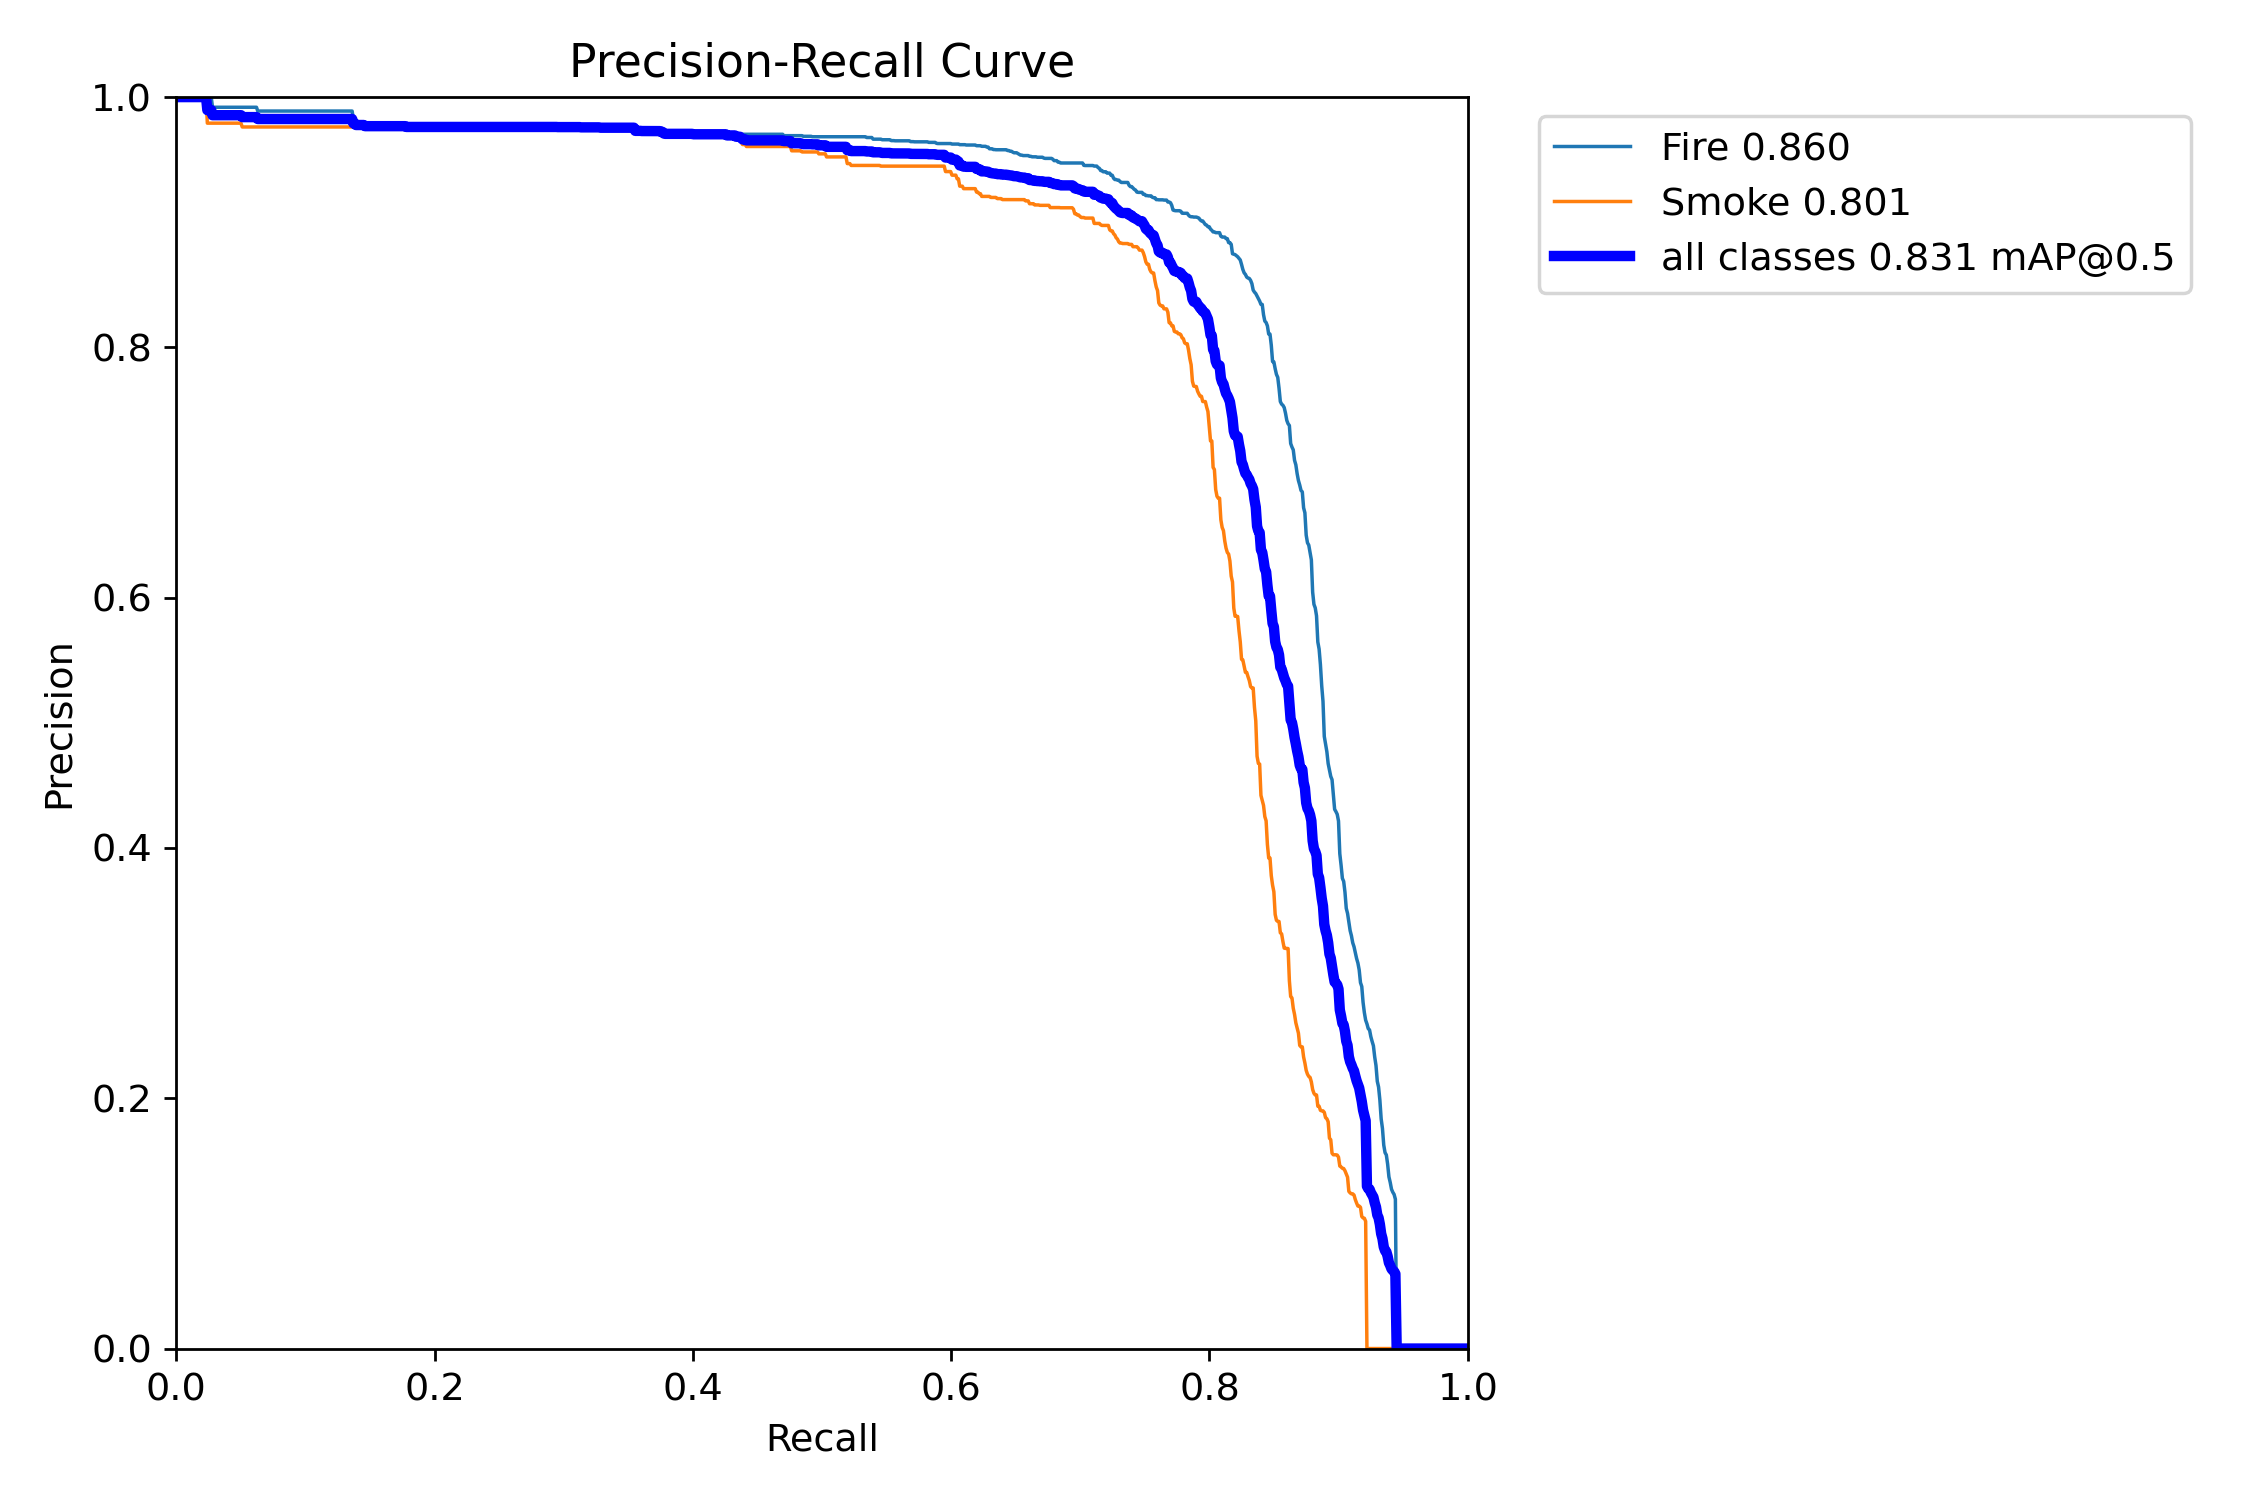

In [24]:
val_run_dir = val_metrics.save_dir

# ---- Confusion matrix, plotted manually for a clear result (no blank cells) ----
cm = val_metrics.confusion_matrix.matrix   # raw counts, shape (nc+1, nc+1), last row/col = background
labels = list(CLASS_NAMES) + ["background"]

# column-wise normalize (each column = one true class, sums to 1)
cm_norm = cm.astype(float)
col_sums = cm_norm.sum(axis=0)
col_sums[col_sums == 0] = 1   # avoid divide-by-zero
cm_norm = cm_norm / col_sums

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("True", fontsize=12)
ax.set_ylabel("Predicted", fontsize=12)
ax.set_title("Validation set Confusion Matrix", fontsize=13)

# write both the normalized value AND the raw count in every cell -- nothing left blank.
# Raw counts matter because normalized-only hides scale: e.g. "0.85" recall for Fire could
# mean 85/100 or 850/1000, and it is the only way to see how many background images were
# actually misclassified as Fire/Smoke vs how many predictions of each class were correct.
# Note: the background/background cell IS meaningful here (fraction of missed
# detections among the "background" true-column, i.e. false negatives), so it
# gets a real computed value like every other cell, not a placeholder.
for i in range(len(labels)):
    for j in range(len(labels)):
        raw_count = int(cm[i, j])
        text = f"{cm_norm[i, j]:.2f}\n({raw_count})"
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax.text(j, i, text, ha="center", va="center", color=color, fontsize=10)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "val_confusion_matrix.png"), dpi=300)
plt.show()

# ---- also save the raw (un-normalized) counts as a CSV, for exact numbers in the report ----
raw_cm_df = pd.DataFrame(cm.astype(int), index=[f"pred_{l}" for l in labels], columns=[f"true_{l}" for l in labels])
raw_cm_df.to_csv(os.path.join(FINAL_DIR, "val_confusion_matrix_raw_counts.csv"))
print("Raw confusion matrix counts (rows = predicted, columns = true):")
print(raw_cm_df.to_string())

# ---- PR curve -- show Ultralytics' original PNG directly (re-plotting with matplotlib
# makes it blurry, so IPython Image is used to keep the original resolution) ----
from IPython.display import Image as IPImage, display

pr_path = os.path.join(val_run_dir, "BoxPR_curve.png")
if os.path.exists(pr_path):
    print("Validation set Precision-Recall Curve:")
    display(IPImage(filename=pr_path, width=800))
    shutil.copy(pr_path, os.path.join(FINAL_DIR, "val_BoxPR_curve.png"))
else:
    print("Not found:", pr_path)

## 10. Inference time & model size

Important for real-time deployment — these numbers will be needed in the thesis/report.

Model file size : 18.06 MB
Total parameters: 9.23 M
Benchmarking on device: cuda
Total test images used: 1715
Average inference time: 20.44 ms/image  (over 1715 images)
Approx FPS: 48.93
           metric  value
    model_size_MB  18.06
     num_params_M   9.23
 avg_inference_ms  20.44
              fps  48.93
           device   cuda
num_images_tested   1715


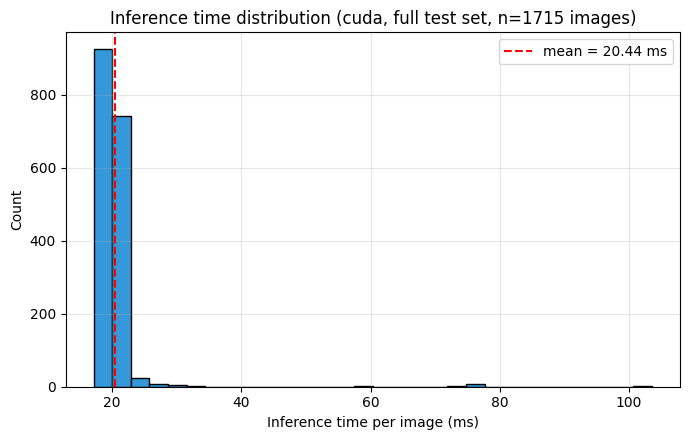

In [25]:
import torch

# ---- model size (file + parameter count) ----
model_size_mb = os.path.getsize(BEST_PT) / (1024 * 1024)
num_params = sum(p.numel() for p in best_model.model.parameters())
num_params_m = num_params / 1e6

print(f"Model file size : {model_size_mb:.2f} MB")
print(f"Total parameters: {num_params_m:.2f} M")

# ---- inference speed benchmark ----
# Previously benchmarked on 100 images, but the "actual" real count is needed,
# so now running on the FULL TEST SET (all images) to get the actual average.
test_images_dir = os.path.join(DATASET_DIR, "test", "images")
test_images = glob.glob(os.path.join(test_images_dir, "*"))   # all test images, not a sample

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Benchmarking on device: {device}")
print(f"Total test images used: {len(test_images)}")

# warm-up run (excludes GPU first-call overhead from the timing)
_ = best_model.predict(test_images[0], imgsz=IMGSZ, verbose=False)

times = []
for img_path in test_images:
    t0 = time.time()
    _ = best_model.predict(img_path, imgsz=IMGSZ, verbose=False, device=device)
    t1 = time.time()
    times.append((t1 - t0) * 1000)   # ms

avg_ms = np.mean(times)
fps = 1000 / avg_ms

print(f"Average inference time: {avg_ms:.2f} ms/image  (over {len(times)} images)")
print(f"Approx FPS: {fps:.2f}")

speed_summary = pd.DataFrame({
    "metric": ["model_size_MB", "num_params_M", "avg_inference_ms", "fps", "device", "num_images_tested"],
    "value": [round(model_size_mb, 2), round(num_params_m, 2), round(avg_ms, 2), round(fps, 2), device, len(times)],
})
speed_summary.to_csv(os.path.join(FINAL_DIR, "speed_and_size.csv"), index=False)
print(speed_summary.to_string(index=False))

# ---- inference time distribution plot ----
plt.figure(figsize=(7, 4.5))
plt.hist(times, bins=30, color="#3498db", edgecolor="black")
plt.axvline(avg_ms, color="red", linestyle="--", label=f"mean = {avg_ms:.2f} ms")
plt.xlabel("Inference time per image (ms)")
plt.ylabel("Count")
plt.title(f"Inference time distribution ({device}, full test set, n={len(times)} images)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FINAL_DIR, "inference_time_distribution.png"), dpi=300)
plt.show()

## 11. Final summary table (for direct use in the report/paper)

In [27]:
summary = {
    "model": "YOLO12s",
    "eval_split": "test",
    "imgsz": IMGSZ,
    "epochs_trained": len(r),
    "batch": BATCH,
    "mAP50": test_metrics.box.map50,
    "mAP50-95": test_metrics.box.map,
    "precision": test_metrics.box.mp,
    "recall": test_metrics.box.mr,
    "model_size_MB": round(model_size_mb, 2),
    "params_M": round(num_params_m, 2),
    "avg_inference_ms": round(avg_ms, 2),
    "fps": round(fps, 2),
}

for name, ap50 in zip(CLASS_NAMES, test_metrics.box.ap50):
    summary[f"{name}_AP50"] = ap50

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(FINAL_DIR, "final_summary.csv"), index=False)
print(summary_df.T.to_string())


                         0
model              YOLO12s
eval_split            test
imgsz                  640
epochs_trained         150
batch                   12
mAP50             0.825934
mAP50-95          0.625119
precision         0.872734
recall            0.761723
model_size_MB        18.06
params_M              9.23
avg_inference_ms     20.44
fps                  48.93
Fire_AP50         0.873089
Smoke_AP50         0.77878


## 12. Save everything + zip (so it can be downloaded even after the Kaggle session ends)

`

In [30]:
# copy best.pt + last.pt into final_outputs
shutil.copy(BEST_PT, os.path.join(FINAL_DIR, "best.pt"))
last_pt = os.path.join(RUN_DIR, "weights", "last.pt")
if os.path.exists(last_pt):
    shutil.copy(last_pt, os.path.join(FINAL_DIR, "last.pt"))

# also copy results.csv + args.yaml (for full training-config reproducibility)
shutil.copy(results_csv, os.path.join(FINAL_DIR, "results.csv"))
args_yaml = os.path.join(RUN_DIR, "args.yaml")
if os.path.exists(args_yaml):
    shutil.copy(args_yaml, os.path.join(FINAL_DIR, "args.yaml"))

zip_path = "/kaggle/working/yolo12s_outputs"
shutil.make_archive(zip_path, "zip", FINAL_DIR)

print("Everything saved in:", FINAL_DIR)
print("Zip file ready at:", zip_path + ".zip")
print("\nFiles included:")
for f in sorted(os.listdir(FINAL_DIR)):
    print(" -", f)

Everything saved in: /kaggle/working/final_outputs
Zip file ready at: /kaggle/working/yolo12s_outputs.zip

Files included:
 - args.yaml
 - best.pt
 - final_summary.csv
 - inference_time_distribution.png
 - last.pt
 - per_class_AP50.png
 - results.csv
 - sample_predictions.png
 - speed_and_size.csv
 - test_BoxPR_curve.png
 - test_confusion_matrix.png
 - test_confusion_matrix_raw_counts.csv
 - test_metrics.csv
 - training_curves.png
 - val_BoxPR_curve.png
 - val_confusion_matrix.png
 - val_confusion_matrix_raw_counts.csv
 - val_metrics.csv
 - val_vs_test.png
